### Evaluación del Modelo YOLOv8 Fine-Tuned (Taxonomía Semántica)
Este bloque carga el modelo entrenado con las clases agrupadas y extrae las métricas de precisión media (mAP) globales y por súper-clase. Estos son los datos definitivos para contrastar con el modelo base.

In [58]:
import os
from pathlib import Path
import ultralytics
import ultralytics.data.utils

# 1. Creamos una carpeta de configuración local dentro de tu workspace (donde SÍ tienes permisos)
local_config_dir = Path.cwd() / "yolo_config_local"
local_config_dir.mkdir(parents=True, exist_ok=True)

# 2. Le decimos a YOLO que use esta carpeta en lugar de tu /home bloqueado
ultralytics.utils.USER_CONFIG_DIR = local_config_dir

# 3. Creamos el archivo Arial falso en tu nueva carpeta permitida
fake_font = local_config_dir / "Arial.ttf"
fake_font.touch()

# 4. Parcheamos directamente la función dentro del archivo exacto donde lanza el error
ultralytics.data.utils.check_font = lambda *args, **kwargs: None

print(f"✅ Configuración redirigida a: {local_config_dir}")
print("✅ Bloqueo de fuente Arial superado. Ya puedes ejecutar el baseline.")

✅ Configuración redirigida a: /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/yolo_config_local
✅ Bloqueo de fuente Arial superado. Ya puedes ejecutar el baseline.


1/4 Preparando dataset temporal (traduciendo IDs a COCO)...
2/4 Evaluando YOLO Base (yolov8s.pt) en dominio egocéntrico para obtener mAP...
Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 4500 Ada Generation, 24088MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 510.9±181.5 MB/s, size: 224.0 KB)
val: Scanning /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/temp_eval_coco/labels/val... 774 images, 579 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 774/774 1.4Kit/s 0.5s0.0ss
val: New cache created: /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/temp_eval_coco/labels/val.cache


/nfs/workspace/sebastian.toro/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/nfs/workspace/sebastian.toro/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ration

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 15.2it/s 3.2s0.1s
                   all        774        211     0.0964      0.199     0.0602     0.0211
                 knife         96        103     0.0715      0.184     0.0605     0.0238
                carrot         99        108      0.121      0.213     0.0599     0.0184
Speed: 0.4ms preprocess, 1.4ms inference, 0.0ms loss, 1.1ms postprocess per image

🏆 mAP@50 GLOBAL (Baseline): 0.0602
- knife_base: AP@50 = 0.0605
- carrot_base: AP@50 = 0.0599

3/4 Analizando imágenes y cruzando cajas (IoU) para la Matriz de Confusión...
4/4 ✅ Generando gráfico...


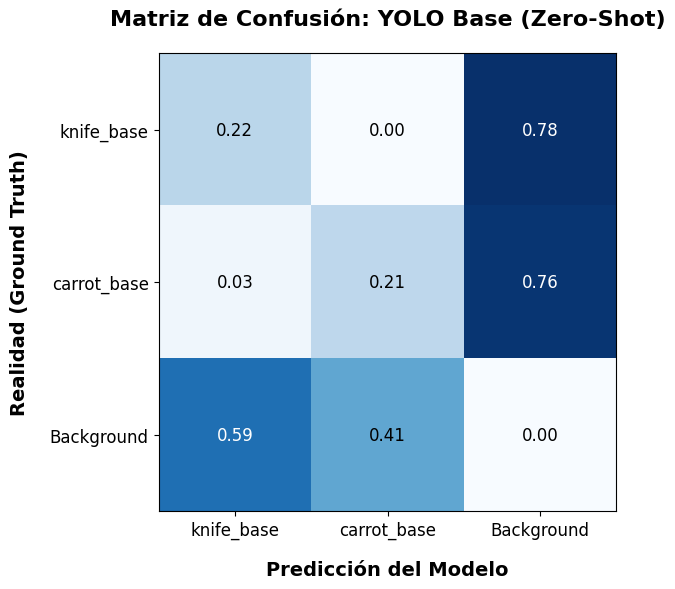

In [59]:
import os
import shutil
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision.ops import box_iou
from ultralytics import YOLO
import ultralytics.utils.checks as checks

# Desactivar chequeo de fuentes si no tienes internet
checks.check_font = lambda *args, **kwargs: None

# ==========================================
# 1. CONFIGURACIÓN (¡Cambia estas rutas si es necesario!)
# ==========================================
DIR_IMAGES_VAL = Path('/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/images')
DIR_LABELS_VAL = Path('/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/labels')

MI_KNIFE_ID = 1   
MI_CARROT_ID = 6  

# ==========================================
# 2. CREAR DATASET TEMPORAL "TRADUCIDO"
# ==========================================
TEMP_DATASET = Path.cwd() / 'temp_eval_coco'
TEMP_IMAGES = TEMP_DATASET / 'images' / 'val'
TEMP_LABELS = TEMP_DATASET / 'labels' / 'val'

if TEMP_DATASET.exists():
    shutil.rmtree(TEMP_DATASET)

TEMP_IMAGES.mkdir(parents=True, exist_ok=True)
TEMP_LABELS.mkdir(parents=True, exist_ok=True)

print("1/4 Preparando dataset temporal (traduciendo IDs a COCO)...")

for img_file in DIR_IMAGES_VAL.glob('*.*'):
    try:
        (TEMP_IMAGES / img_file.name).symlink_to(img_file)
    except OSError:
        shutil.copy(img_file, TEMP_IMAGES / img_file.name)

for label_file in DIR_LABELS_VAL.glob('*.txt'):
    with open(label_file, 'r') as f:
        lines = f.readlines()
    
    nuevas_lineas = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) > 0:
            cls_id = int(parts[0])
            if cls_id == MI_KNIFE_ID:
                parts[0] = '43' 
                nuevas_lineas.append(' '.join(parts))
            elif cls_id == MI_CARROT_ID:
                parts[0] = '51' 
                nuevas_lineas.append(' '.join(parts))
                
    with open(TEMP_LABELS / label_file.name, 'w') as f:
        f.write('\n'.join(nuevas_lineas))

yaml_dict = {
    'path': str(TEMP_DATASET),
    'train': 'images/val',  
    'val': 'images/val',
    'names': {i: f'class_{i}' for i in range(80)}
}
yaml_dict['names'][43] = 'knife_base'
yaml_dict['names'][51] = 'carrot_base'

yaml_path = TEMP_DATASET / 'eval_coco.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_dict, f)

# ==========================================
# 3. EJECUTAR VALIDACIÓN OFICIAL (mAP)
# ==========================================
print("2/4 Evaluando YOLO Base (yolov8s.pt) en dominio egocéntrico para obtener mAP...")
model_base = YOLO('yolov8s.pt') 

metrics = model_base.val(
    data=str(yaml_path),
    split='val',
    plots=False, # Mantenemos esto en False para evitar el error de Arial.ttf
    project=str(Path.cwd() / "runs_base"),
    name='validacion_zero_shot',
    classes=[43, 51] 
)

print("\n🏆 mAP@50 GLOBAL (Baseline):", round(metrics.box.map50, 4))
class_indices = metrics.ap_class_index
for i, class_idx in enumerate(class_indices):
    print(f"- {yaml_dict['names'][class_idx]}: AP@50 = {metrics.box.ap50[i]:.4f}")

# ==========================================
# 4. CALCULAR MATRIZ DE CONFUSIÓN MANUALMENTE
# ==========================================
print("\n3/4 Analizando imágenes y cruzando cajas (IoU) para la Matriz de Confusión...")

# Mapeamos los IDs de COCO (43 y 51) a posiciones de la matriz (0 y 1)
class_map = {43: 0, 51: 1}
nombres_clases = ['knife_base', 'carrot_base', 'Background']
num_clases = len(nombres_clases)

matriz = np.zeros((num_clases, num_clases), dtype=np.int32)

CONF_THRESH = 0.25 
IOU_THRESH = 0.45  

archivos_img = list(TEMP_IMAGES.glob("*.*"))

for img_path in archivos_img:
    # 1. Leer etiquetas reales traducidas
    label_path = TEMP_LABELS / (img_path.stem + ".txt")
    true_boxes = []
    true_classes = []
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                c_id = int(parts[0])
                if c_id in class_map: # Solo procesamos cuchillos y zanahorias
                    xc, yc, w, h = map(float, parts[1:5])
                    x1, y1, x2, y2 = xc - w/2, yc - h/2, xc + w/2, yc + h/2
                    true_boxes.append([x1, y1, x2, y2])
                    true_classes.append(class_map[c_id])
                
    true_boxes = torch.tensor(true_boxes) if true_boxes else torch.empty((0, 4))
    
    # 2. Hacer predicción forzando a buscar solo 43 y 51
    results = model_base(str(img_path), verbose=False, conf=CONF_THRESH, classes=[43, 51])[0]
    
    pred_boxes = []
    pred_classes = []
    if len(results.boxes) > 0:
        img_h, img_w = results.orig_shape
        for box in results.boxes:
            c_id = int(box.cls[0])
            if c_id in class_map:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                pred_boxes.append([x1/img_w, y1/img_h, x2/img_w, y2/img_h])
                pred_classes.append(class_map[c_id])
            
    pred_boxes = torch.tensor(pred_boxes) if pred_boxes else torch.empty((0, 4))
    
    # 3. Cruzar cajas
    matched_true = set()
    matched_pred = set()
    
    if len(true_boxes) > 0 and len(pred_boxes) > 0:
        ious = box_iou(true_boxes, pred_boxes)
        for t_idx, t_class in enumerate(true_classes):
            mejores_preds = torch.where(ious[t_idx] > IOU_THRESH)[0]
            if len(mejores_preds) > 0:
                p_idx = mejores_preds[torch.argmax(ious[t_idx][mejores_preds])].item()
                p_class = pred_classes[p_idx]
                
                if p_idx not in matched_pred:
                    matriz[t_class, p_class] += 1
                    matched_true.add(t_idx)
                    matched_pred.add(p_idx)
                    
    # Falsos Negativos
    for t_idx, t_class in enumerate(true_classes):
        if t_idx not in matched_true: matriz[t_class, num_clases-1] += 1
            
    # Falsos Positivos
    for p_idx, p_class in enumerate(pred_classes):
        if p_idx not in matched_pred: matriz[num_clases-1, p_class] += 1

print("4/4 ✅ Generando gráfico...")

# ==========================================
# 5. DIBUJAR MATRIZ DE CONFUSIÓN
# ==========================================
suma_filas = matriz.sum(axis=1, keepdims=True)
matriz_norm = np.divide(matriz, suma_filas, out=np.zeros_like(matriz, dtype=float), where=suma_filas!=0)

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(matriz_norm, cmap='Blues')

for i in range(matriz_norm.shape[0]):
    for j in range(matriz_norm.shape[1]):
        valor = matriz_norm[i, j]
        color_texto = "white" if valor > 0.5 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color_texto, fontsize=12)

ax.set_xticks(np.arange(len(nombres_clases)))
ax.set_yticks(np.arange(len(nombres_clases)))
ax.xaxis.set_ticks_position('bottom')
ax.set_xticklabels(nombres_clases, fontsize=12)
ax.set_yticklabels(nombres_clases, fontsize=12)

plt.xlabel("Predicción del Modelo", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("Realidad (Ground Truth)", fontsize=14, fontweight='bold', labelpad=15)
plt.title("Matriz de Confusión: YOLO Base (Zero-Shot)", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [60]:
from ultralytics import YOLO
import pandas as pd
from IPython.display import display

# 1. Cargar el modelo entrenado
# Ajusta la ruta a donde se hayan guardado los pesos de tu entrenamiento
model_path = "/nfs/workspace/sebastian.toro/runs/detect/epic_full_epoch7/weights/best.pt" 
model = YOLO(model_path)

print("✅ Modelo cargado correctamente.")

✅ Modelo cargado correctamente.


In [61]:
# 2. Ejecutar la validación
# Ajusta la ruta a tu archivo .yaml que contiene las 8 súper-clases
dataset_yaml = '/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/dataset.yaml'

print("Iniciando evaluación en el conjunto de validación...")
# Si usaste un split de test específico, cambia split='val' a split='test'
metrics = model.val(
    data=dataset_yaml, 
    split='val', 
    plots=False,
    project="/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data",
    name='validacion_epic'            
)
print("✅ Evaluación completada.")

Iniciando evaluación en el conjunto de validación...
Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 4500 Ada Generation, 24088MiB)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2102.0±354.8 MB/s, size: 223.8 KB)
val: Scanning /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/labels.cache... 774 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 774/774 249.7Mit/s 0.0s


/nfs/workspace/sebastian.toro/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/nfs/workspace/sebastian.toro/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ration

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 14.1it/s 3.5s0.2s
                   all        774        859      0.719      0.675      0.707       0.37
                 bread        100        111      0.802      0.764      0.842      0.526
                 knife         96        103       0.65       0.45       0.46      0.174
                cheese         88        104      0.704      0.683      0.659      0.315
                  meat         97        101      0.725      0.743      0.791       0.43
                tomato         98        121      0.766      0.736      0.779      0.409
            vegetables         98        109      0.624      0.578      0.588      0.267
                carrot         99        108      0.756      0.722      0.778      0.417
                 sauce         98        102      0.727      0.725       0.76      0.423
Speed: 0.3ms preprocess, 1.3ms inference, 0.0ms loss, 0.8ms postpro

In [62]:
# 3. Extraer e imprimir Métricas Globales
map50 = metrics.box.map50  
map50_95 = metrics.box.map 
precision = metrics.box.mp 
recall = metrics.box.mr    

print("="*40)
print("🏆 MÉTRICAS GLOBALES DEL MODELO")
print("="*40)
print(f"mAP@50:          {map50:.4f}" )
print(f"mAP@50-95:       {map50_95:.4f}")
print(f"Precisión Media: {precision:.4f}")
print(f"Recall Medio:    {recall:.4f}")

🏆 MÉTRICAS GLOBALES DEL MODELO
mAP@50:          0.7069
mAP@50-95:       0.3701
Precisión Media: 0.7193
Recall Medio:    0.6752


In [63]:
# 4. Extraer y formatear Métricas por Súper-Clase
print("="*40)
print("📊 RENDIMIENTO POR SÚPER-CLASE")
print("="*40)

class_indices = metrics.ap_class_index
class_names = metrics.names

class_data = []
for i, class_idx in enumerate(class_indices):
    name = class_names[class_idx]
    ap50 = metrics.box.ap50[i]
    ap50_95 = metrics.box.ap[i]
    class_data.append({
        'Super-Clase': name, 
        'AP@50': round(ap50, 4),
        'AP@50-95': round(ap50_95, 4)
    })

# Crear DataFrame y ordenar de mayor a menor precisión
df_metrics = pd.DataFrame(class_data)
df_metrics = df_metrics.sort_values(by='AP@50', ascending=False).reset_index(drop=True)

# Usamos display() para que Jupyter renderice una tabla HTML bonita
display(df_metrics)

📊 RENDIMIENTO POR SÚPER-CLASE


,Super-Clase,AP@50,AP@50-95
0,bread,0.8416,0.5259
1,meat,0.7907,0.4296
2,tomato,0.7785,0.4087
3,carrot,0.7777,0.4169
4,sauce,0.7604,0.4231
5,cheese,0.6585,0.3147
6,vegetables,0.5877,0.2672
7,knife,0.4600,0.1745


🔍 Analizando imágenes y cruzando cajas (IoU)... Esto tomará unos segundos.


✅ Cálculo completado. Dibujando gráfico...


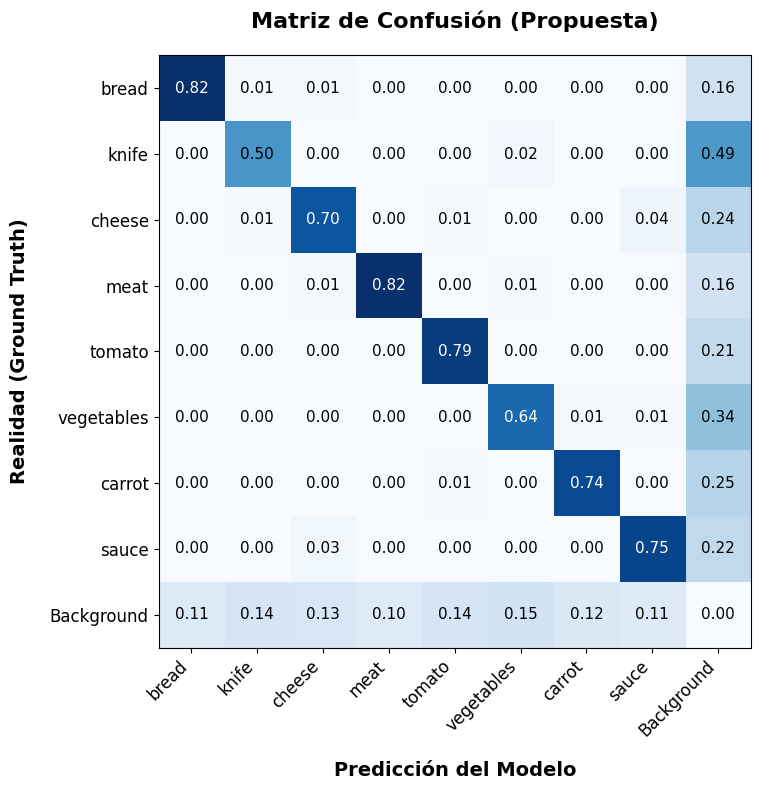

In [64]:
import os
import glob
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
from ultralytics import YOLO

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
# Carga TU modelo (Asegúrate de que la ruta sea la correcta)
MODEL_PATH = "/nfs/workspace/sebastian.toro/runs/detect/epic_full_epoch7/weights/best.pt"
model = YOLO(MODEL_PATH)

# Rutas a tus imágenes y etiquetas (Ground Truth) de validación
DIR_IMAGES = Path("/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/images")
DIR_LABELS = Path("/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/labels")

# Clases de tu modelo (asegúrate de que el orden coincide con tus IDs, 0 al 7)
nombres_clases = ['bread', 'knife', 'cheese', 'meat', 'tomato', 'vegetables', 'carrot', 'sauce', 'Background']
num_clases = len(nombres_clases)

# Inicializamos la matriz de confusión con ceros
matriz = np.zeros((num_clases, num_clases), dtype=np.int32)

print("🔍 Analizando imágenes y cruzando cajas (IoU)... Esto tomará unos segundos.")

# ==========================================
# 2. CALCULAR MATRIZ MANUALMENTE
# ==========================================
CONF_THRESH = 0.25 # Confianza mínima para considerar una detección
IOU_THRESH = 0.45  # Solapamiento mínimo para considerar que le "atinó" al objeto

archivos_img = list(DIR_IMAGES.glob("*.*"))

for img_path in archivos_img:
    # 1. Leer etiquetas reales (Ground Truth)
    label_path = DIR_LABELS / (img_path.stem + ".txt")
    true_boxes = []
    true_classes = []
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                c_id = int(parts[0])
                # YOLO format: cls x_center y_center w h (normalizados)
                # Convertimos a formato [x1, y1, x2, y2]
                xc, yc, w, h = map(float, parts[1:5])
                x1, y1, x2, y2 = xc - w/2, yc - h/2, xc + w/2, yc + h/2
                true_boxes.append([x1, y1, x2, y2])
                true_classes.append(c_id)
                
    true_boxes = torch.tensor(true_boxes) if true_boxes else torch.empty((0, 4))
    
    # 2. Hacer predicción con el modelo
    results = model(str(img_path), verbose=False, conf=CONF_THRESH)[0]
    
    pred_boxes = []
    pred_classes = []
    if len(results.boxes) > 0:
        # Extraer cajas predichas y normalizarlas de 0 a 1 (dividimos por tamaño de img)
        img_h, img_w = results.orig_shape
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            # Normalizar al mismo formato que las etiquetas
            pred_boxes.append([x1/img_w, y1/img_h, x2/img_w, y2/img_h])
            pred_classes.append(int(box.cls[0]))
            
    pred_boxes = torch.tensor(pred_boxes) if pred_boxes else torch.empty((0, 4))
    
    # 3. Cruzar cajas reales con predichas (Cálculo de Matriz)
    matched_true = set()
    matched_pred = set()
    
    if len(true_boxes) > 0 and len(pred_boxes) > 0:
        ious = box_iou(true_boxes, pred_boxes)
        # Para cada caja real, encontrar la mejor predicción
        for t_idx, t_class in enumerate(true_classes):
            mejores_preds = torch.where(ious[t_idx] > IOU_THRESH)[0]
            if len(mejores_preds) > 0:
                # Tomamos la que tenga mayor IoU
                p_idx = mejores_preds[torch.argmax(ious[t_idx][mejores_preds])].item()
                p_class = pred_classes[p_idx]
                
                if p_idx not in matched_pred:
                    matriz[t_class, p_class] += 1
                    matched_true.add(t_idx)
                    matched_pred.add(p_idx)
                    
    # Falsos Negativos (No detectados -> Background)
    for t_idx, t_class in enumerate(true_classes):
        if t_idx not in matched_true:
            matriz[t_class, num_clases-1] += 1
            
    # Falsos Positivos (Alucinaciones -> Background)
    for p_idx, p_class in enumerate(pred_classes):
        if p_idx not in matched_pred:
            matriz[num_clases-1, p_class] += 1

print("✅ Cálculo completado. Dibujando gráfico...")

# ==========================================
# 3. DIBUJAR GRÁFICO (Matplotlib puro)
# ==========================================
# Normalizar por filas
suma_filas = matriz.sum(axis=1, keepdims=True)
matriz_norm = np.divide(matriz, suma_filas, out=np.zeros_like(matriz, dtype=float), where=suma_filas!=0)

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(matriz_norm, cmap='Blues')

for i in range(matriz_norm.shape[0]):
    for j in range(matriz_norm.shape[1]):
        valor = matriz_norm[i, j]
        color_texto = "white" if valor > 0.5 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color_texto, fontsize=11)

ax.set_xticks(np.arange(len(nombres_clases)))
ax.set_yticks(np.arange(len(nombres_clases)))
ax.xaxis.set_ticks_position('bottom')
ax.set_xticklabels(nombres_clases, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(nombres_clases, fontsize=12)

plt.xlabel("Predicción del Modelo", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("Realidad (Ground Truth)", fontsize=14, fontweight='bold', labelpad=15)
plt.title("Matriz de Confusión (Propuesta)", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()